# modeling_v5 — 신뢰도 측정 (예측별 신뢰구간 + 모델 신뢰도 진단)

v5 예측에 **"이 예측을 얼마나 믿을 수 있는가"**를 더합니다. 전부 **valid_data로 검증**.

1. **예측별 신뢰구간 (Split Conformal)** — 각 wafer에 `[하한, 상한]`. train OOF 잔차로 보정, valid에서 실제 커버리지 검증. 유한표본 커버리지 보장.
2. **불확실성 점수 (Fold Disagreement)** — 5개 fold 모델 예측의 표준편차. 높을수록 저신뢰. valid에서 "σ↑ → 오차↑" 유효성 검증.
3. **모델 신뢰도 진단** — 신뢰도 곡선, 예측 vs 실제, 예측 구간별 RMSE, σ 구간별 오차.

> v5는 WF 집계 피처에 의존해 WF 내 row 예측이 거의 동일(within-WF std≈0)하므로, 불확실성 신호로 **fold 불일치**를 사용.

## Cell 1 — imports

In [1]:
import numpy as np, pandas as pd, json, warnings
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]=(11,4)

DATA_DIR=Path("../문제1(하)"); ANS_DIR=Path("../문제1_하_answer")
OUT=Path("outputs"); OUT.mkdir(exist_ok=True)
WF_ID,TARGET,N_FOLDS="C64","C65",5

## Cell 2 — 데이터 로드

In [2]:
train=pd.read_csv(DATA_DIR/"train_data.csv")
valid_X=pd.read_csv(DATA_DIR/"valid_X.csv"); test_X=pd.read_csv(DATA_DIR/"test_X.csv")
valid_Yp=pd.read_csv(DATA_DIR/"valid_Y_problem.csv"); test_Yp=pd.read_csv(DATA_DIR/"test_Y_problem.csv")
valid_Ya=pd.read_csv(ANS_DIR/"valid_Y_answer.csv").set_index("C64")["C65"]
test_Ya =pd.read_csv(ANS_DIR/"test_Y_answer.csv").set_index("C64")["C65"]
cols=[c for c in train.columns if c!=TARGET]; valid_X=valid_X[cols]; test_X=test_X[cols]

## Cell 3 — v5 row-level 피처 (원본 v5와 동일)

In [3]:
DROP_IDS=["C34","C35","C38"]; DROP_LOT=["C20","C21","C22"]; DROP_CONST=["C14","C24","C30"]
DROP_EXCL=["C26","C28","C29","C37"]; DROP_ALLNA=["C2","C13","C43","C47","C53","C55"]
DROP_TIME=["C10","C39","C40","C41"]; DROP_DUP=["C36"]
DROP_ALL=DROP_IDS+DROP_LOT+DROP_CONST+DROP_EXCL+DROP_ALLNA+DROP_TIME+DROP_DUP
CAT_COLS=["C6","C7"]; TE_COL="C23"

def build_rows(df, has_target=True):
    df=df.copy()
    excl=set([WF_ID,TARGET]+DROP_ALL+CAT_COLS+[TE_COL])
    sensors=[c for c in df.select_dtypes(include=[np.number]).columns if c not in excl]
    g=df.groupby(WF_ID)
    ctx=g[sensors].agg(["mean","std","min","max"]); ctx.columns=[f"{c}_wf_{s}" for c,s in ctx.columns]
    ctx["wf_nrows"]=g.size(); df=df.merge(ctx,on=WF_ID,how="left")
    df["row_pos"]=g.cumcount()
    feat_cols=sensors+list(ctx.columns)+["row_pos"]+CAT_COLS
    for c in CAT_COLS: df[c]=df[c].astype("category")
    out=df[[WF_ID]+feat_cols].copy(); out[TE_COL]=df[TE_COL].values
    if has_target: out[TARGET]=df[TARGET].values
    return out, feat_cols

tr_rows,FEATS=build_rows(train,True); va_rows,_=build_rows(valid_X,False); te_rows,_=build_rows(test_X,False)
def te_fit(frame,col,target,m=20):
    prior=frame[target].mean(); agg=frame.groupby(col)[target].agg(["mean","count"])
    return (agg["mean"]*agg["count"]+prior*m)/(agg["count"]+m), prior
print("row 피처:", len(FEATS)+1)

row 피처: 185


## Cell 4 — GroupKFold 학습 (OOF + **fold별** 예측 수집)

In [4]:
PARAMS=dict(objective="regression",metric="rmse",boosting_type="gbdt",
    learning_rate=0.03,num_leaves=127,max_depth=-1,min_child_samples=50,
    subsample=0.8,subsample_freq=1,colsample_bytree=0.7,reg_alpha=0.5,reg_lambda=1.0,
    n_estimators=4000,random_state=42,n_jobs=-1,verbose=-1)

y=tr_rows[TARGET].values; gr=tr_rows[WF_ID].astype("category").cat.codes.values
gkf=GroupKFold(N_FOLDS); USE=FEATS+[TE_COL+"_te"]
oof=np.zeros(len(tr_rows))
va_fold=np.zeros((N_FOLDS,len(va_rows))); te_fold=np.zeros((N_FOLDS,len(te_rows)))
for k,(tri,vai) in enumerate(gkf.split(tr_rows,y,gr)):
    tf=tr_rows.iloc[tri].copy(); vf=tr_rows.iloc[vai].copy()
    enc,prior=te_fit(tf,TE_COL,TARGET)
    for d in (tf,vf): d[TE_COL+"_te"]=d[TE_COL].map(enc).fillna(prior)
    va_k=va_rows.copy(); te_k=te_rows.copy()
    va_k[TE_COL+"_te"]=va_k[TE_COL].map(enc).fillna(prior); te_k[TE_COL+"_te"]=te_k[TE_COL].map(enc).fillna(prior)
    m=lgb.LGBMRegressor(**PARAMS)
    m.fit(tf[USE],tf[TARGET],eval_set=[(vf[USE],vf[TARGET])],categorical_feature=CAT_COLS,
          callbacks=[lgb.early_stopping(100,verbose=False),lgb.log_evaluation(0)])
    oof[vai]=m.predict(vf[USE])
    va_fold[k]=m.predict(va_k[USE]); te_fold[k]=m.predict(te_k[USE])
    print(f"fold{k+1} done")

fold1 done
fold2 done
fold3 done
fold4 done
fold5 done


## Cell 5 — WF 집계 + 불확실성(σ)=fold 불일치 (단일 groupby, pandas 3.0 안전)

In [5]:
def rows_to_wf(rows, rowpred):
    wf=rows[WF_ID].to_numpy()
    s=pd.Series(rowpred, index=pd.Index(wf, name=WF_ID))
    return s.groupby(level=0, sort=True).mean()

def fold_wf_matrix(rows, fold_mat):
    # fold_mat:(N_FOLDS,n_rows) → (n_wf,N_FOLDS) 1회 groupby → fold 평균/표준편차
    df=pd.DataFrame(fold_mat.T); df[WF_ID]=rows[WF_ID].to_numpy()
    wf_fold=df.groupby(WF_ID, sort=True).mean()
    return wf_fold.mean(axis=1), wf_fold.std(axis=1)

oof_pred=rows_to_wf(tr_rows, oof)
y_wf=tr_rows.groupby(WF_ID)[TARGET].first().reindex(oof_pred.index)
va_pred,va_sig=fold_wf_matrix(va_rows, va_fold)
te_pred,te_sig=fold_wf_matrix(te_rows, te_fold)

assert len(va_pred)==valid_Ya.shape[0], f"valid WF수 불일치 {len(va_pred)} vs {valid_Ya.shape[0]}"
print("valid/test WF수:", len(va_pred), len(te_pred), "(각 1990 정상)")
print("CV OOF RMSE:", round(np.sqrt(mean_squared_error(y_wf, oof_pred)),3))
print("Valid RMSE :", round(np.sqrt(mean_squared_error(valid_Ya.loc[va_pred.index], va_pred)),3))
print("fold 불일치 σ — valid median %.1f"%va_sig.median())

valid/test WF수: 1990 1990 (각 1990 정상)
CV OOF RMSE: 62.634
Valid RMSE : 61.384
fold 불일치 σ — valid median 7.5


## Cell 6 — Split Conformal 신뢰구간 보정 (train OOF)

In [6]:
oof_res=np.abs(y_wf.values - oof_pred.values); n=len(oof_res)
def q_at(level): return float(np.quantile(oof_res, min(np.ceil((n+1)*level)/n, 1.0)))
print("90%% 반너비 q = %.1f (구간너비 %.0f)"%(q_at(0.9), 2*q_at(0.9)))

90% 반너비 q = 101.5 (구간너비 203)


## Cell 7 — valid_data 커버리지 검증 (신뢰도 곡선)

  목표  valid_실제커버리지    구간너비
0.50         0.503  67.503
0.60         0.596  86.314
0.70         0.698 111.682
0.80         0.809 145.364
0.90         0.904 203.058
0.95         0.950 254.000


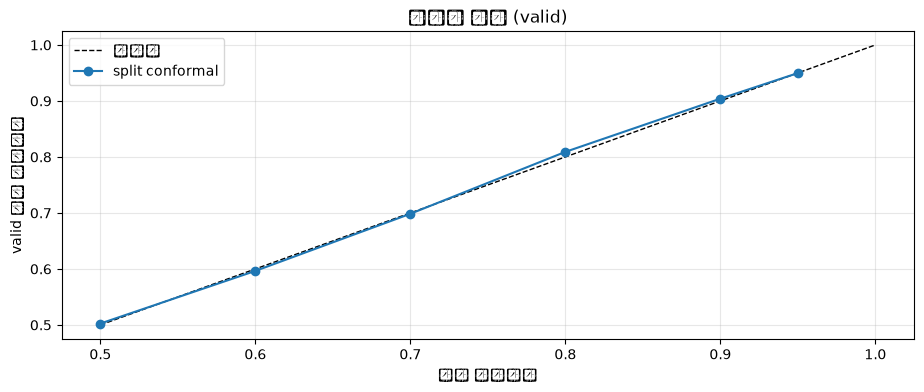

In [7]:
levels=[0.5,0.6,0.7,0.8,0.9,0.95]
va_err=np.abs(valid_Ya.loc[va_pred.index].values - va_pred.values)
rel=pd.DataFrame([[lv,(va_err<=q_at(lv)).mean(),2*q_at(lv)] for lv in levels],
                 columns=["목표","valid_실제커버리지","구간너비"])
print(rel.round(3).to_string(index=False))
plt.plot([0.5,1],[0.5,1],"k--",lw=1,label="이상적")
plt.plot(rel["목표"],rel["valid_실제커버리지"],"o-",label="split conformal")
plt.xlabel("목표 커버리지"); plt.ylabel("valid 실제 커버리지")
plt.title("신뢰도 곡선 (valid)"); plt.legend(); plt.grid(alpha=.3); plt.show()

## Cell 8 — 모델 신뢰도 진단 (valid): σ 유효성 포함

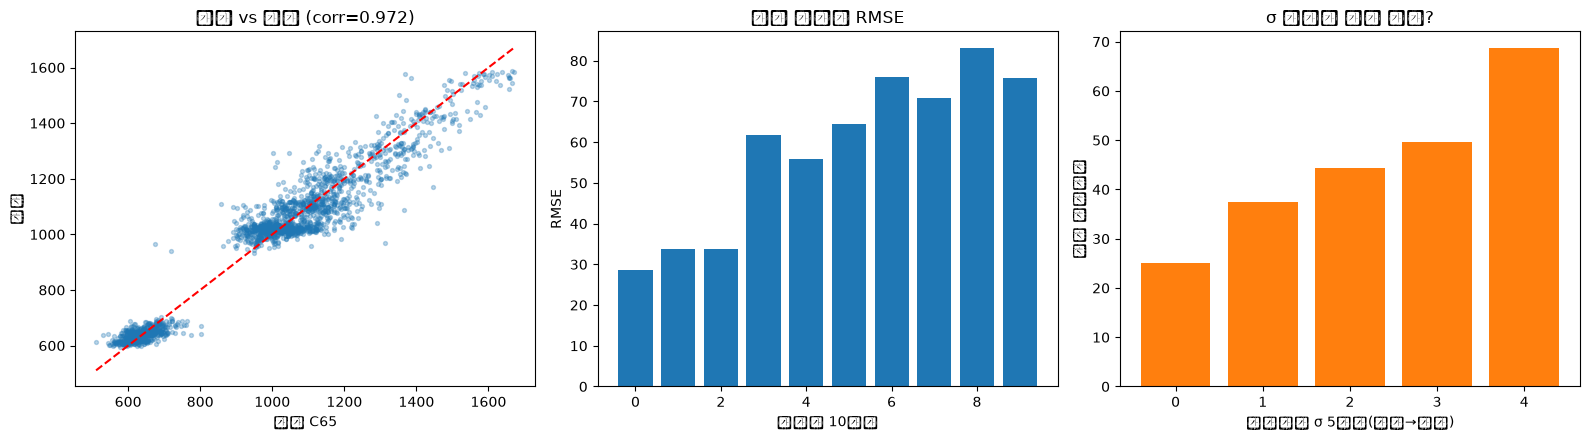

σ vs 실제오차 상관: 0.34
σ 5분위별 평균오차: [25.0, 37.5, 44.4, 49.6, 68.7]


In [8]:
va_ans=valid_Ya.loc[va_pred.index].values; vp=va_pred.values
fig,ax=plt.subplots(1,3,figsize=(16,4.5))
ax[0].scatter(va_ans,vp,s=8,alpha=.3); lim=[va_ans.min(),va_ans.max()]
ax[0].plot(lim,lim,"r--"); ax[0].set_xlabel("실제 C65"); ax[0].set_ylabel("예측")
ax[0].set_title(f"예측 vs 실제 (corr={np.corrcoef(va_ans,vp)[0,1]:.3f})")
dfm=pd.DataFrame({"pred":vp,"ans":va_ans}); dfm["bin"]=pd.qcut(dfm["pred"],10,duplicates="drop")
by=dfm.groupby("bin",observed=True).apply(lambda d:np.sqrt(mean_squared_error(d["ans"],d["pred"])))
ax[1].bar(range(len(by)),by.values); ax[1].set_xlabel("예측값 10분위"); ax[1].set_ylabel("RMSE"); ax[1].set_title("예측 구간별 RMSE")
dfu=pd.DataFrame({"sig":va_sig.values,"err":va_err}); dfu["sb"]=pd.qcut(dfu["sig"],5,duplicates="drop",labels=False)
gg=dfu.groupby("sb",observed=True)["err"].mean()
ax[2].bar(range(len(gg)),gg.values,color="tab:orange")
ax[2].set_xlabel("불확실성 σ 5분위(낮음→높음)"); ax[2].set_ylabel("평균 절대오차"); ax[2].set_title("σ 클수록 오차 큰가?")
plt.tight_layout(); plt.show()
print("σ vs 실제오차 상관:", round(np.corrcoef(va_sig.values,va_err)[0,1],3))
print("σ 5분위별 평균오차:", gg.round(1).tolist())

## Cell 9 — 예측별 신뢰도 테이블 저장 (valid & test)

In [9]:
def conf_table(pred, sig, level=0.9):
    q=q_at(level); thr=np.quantile(sig.values,0.8)
    return pd.DataFrame({WF_ID:pred.index,"pred":pred.values,"sigma":sig.values,
        "lower":pred.values-q,"upper":pred.values+q,"half_width":q,
        "confidence":np.where(sig.values>=thr,"LOW","OK")})
conf_table(va_pred,va_sig).to_csv(OUT/"valid_confidence.csv",index=False)
conf_table(te_pred,te_sig).to_csv(OUT/"test_confidence.csv",index=False)
va_err=np.abs(valid_Ya.loc[va_pred.index].values-va_pred.values)
summary={"valid_rmse":round(float(np.sqrt(mean_squared_error(valid_Ya.loc[va_pred.index],va_pred))),3),
 "n_valid_wf":int(len(va_pred)),
 "cov90":round(float((va_err<=q_at(0.9)).mean()),3),"width90":round(float(2*q_at(0.9)),1),
 "sigma_error_corr":round(float(np.corrcoef(va_sig.values,va_err)[0,1]),3)}
json.dump(summary, open(OUT/"confidence_report.json","w"), indent=2, ensure_ascii=False)
print(json.dumps(summary,ensure_ascii=False,indent=2))
print("\n저장: valid_confidence.csv, test_confidence.csv, confidence_report.json")

{
  "valid_rmse": 61.384,
  "n_valid_wf": 1990,
  "cov90": 0.904,
  "width90": 203.1,
  "sigma_error_corr": 0.34
}

저장: valid_confidence.csv, test_confidence.csv, confidence_report.json
